# Feature Engineering

<div>
Trabajo Integrador<br>
Maestría en Analítica e Inteligencia de Negocios<br>
Universidad del Valle<br>

</div>

#### Student
Camilo Andrés Jaramillo Tarapues - 2402218 

## Libraries

In [1]:
# Libraries

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold

from sklearn.ensemble import RandomForestRegressor

## Dataset

In [2]:
# Cargar el conjunto de datos
df = pd.read_csv('../../data/out/dataset_preprocessed.csv')
df.head()

,FECHA_HORA,FECHA,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO,...,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPC_VAR_YOY_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT,IPP_VAR_PN_YOY_PCT,IPP_VAR_OI_YOY_PCT
0,2020-01-01 00:00:00,2020-01-01,0,72.02,2109637.93,4418103.51,0.0,28880.74,4291.34,1.0,...,130.459523,240.075697,0.0,585.085344,0.42,1.61,-0.73,-0.02,4.7,4.4
1,2020-01-01 01:00:00,2020-01-01,1,136.71,1864989.80,4548853.97,0.0,29107.37,3511.94,1.0,...,130.459523,240.075697,0.0,585.085344,0.42,1.61,-0.73,-0.02,4.7,4.4
2,2020-01-01 02:00:00,2020-01-01,2,127.71,1720883.01,4525898.75,0.0,25939.87,2641.90,1.0,...,130.459523,240.075697,0.0,585.085344,0.42,1.61,-0.73,-0.02,4.7,4.4
3,2020-01-01 03:00:00,2020-01-01,3,127.71,1649014.61,4458645.56,0.0,25651.57,3032.30,1.0,...,130.459523,240.075697,0.0,585.085344,0.42,1.61,-0.73,-0.02,4.7,4.4
4,2020-01-01 04:00:00,2020-01-01,4,127.71,1711745.36,4279657.90,0.0,25245.37,2514.76,1.0,...,130.459523,240.075697,0.0,585.085344,0.42,1.61,-0.73,-0.02,4.7,4.4


### Extract year, month and day from FECHA column

In [3]:
# Ensure the 'FECHA' column is in datetime format
df['FECHA'] = pd.to_datetime(df['FECHA'])

# Create separate columns for year, month, and day
df['YEAR'] = df['FECHA'].dt.year
df['MONTH'] = df['FECHA'].dt.month
df['DAY'] = df['FECHA'].dt.day

# Reorder columns 'YEAR', 'MONTH', 'DAY'
df = df[['YEAR', 'MONTH', 'DAY'] + [col for col in df.columns if col not in ['YEAR', 'MONTH', 'DAY']]]


print("Extracted YEAR, MONTH, and DAY from 'FECHA'.")

Extracted YEAR, MONTH, and DAY from 'FECHA'.


In [4]:
df.head()

,YEAR,MONTH,DAY,FECHA_HORA,FECHA,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,...,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPC_VAR_YOY_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT,IPP_VAR_PN_YOY_PCT,IPP_VAR_OI_YOY_PCT
0,2020,1,1,2020-01-01 00:00:00,2020-01-01,0,72.02,2109637.93,4418103.51,0.0,...,130.459523,240.075697,0.0,585.085344,0.42,1.61,-0.73,-0.02,4.7,4.4
1,2020,1,1,2020-01-01 01:00:00,2020-01-01,1,136.71,1864989.80,4548853.97,0.0,...,130.459523,240.075697,0.0,585.085344,0.42,1.61,-0.73,-0.02,4.7,4.4
2,2020,1,1,2020-01-01 02:00:00,2020-01-01,2,127.71,1720883.01,4525898.75,0.0,...,130.459523,240.075697,0.0,585.085344,0.42,1.61,-0.73,-0.02,4.7,4.4
3,2020,1,1,2020-01-01 03:00:00,2020-01-01,3,127.71,1649014.61,4458645.56,0.0,...,130.459523,240.075697,0.0,585.085344,0.42,1.61,-0.73,-0.02,4.7,4.4
4,2020,1,1,2020-01-01 04:00:00,2020-01-01,4,127.71,1711745.36,4279657.90,0.0,...,130.459523,240.075697,0.0,585.085344,0.42,1.61,-0.73,-0.02,4.7,4.4


<hr>

## Filter columns based on logical criteria

<b>Explanation:</b>
- Remove 'FECHA_HORA' since it acts only as a temporal identifier.
- Remove 'FECHA' becauses it was divide into YEAR, MONTH and YEAR.
- Remove 'IPC_VAR_YOY_PCT', 'IPP_VAR_PN_YOY_PCT', 'IPP_VAR_OI_YOY_PCT' because they represent Year-over-Year (YOY) variations. In this project, we focus on Month-over-Month (MOM) variations as they are more relevant for short-term predictions.

In [5]:
# =====================================
# 2. FILTER COLUMNS BASED ON LOGICAL CRITERIA
# =====================================

columns_to_drop = [
    "FECHA_HORA",
    "FECHA",
    "IPC_VAR_YOY_PCT",
    "IPP_VAR_PN_YOY_PCT",
    "IPP_VAR_OI_YOY_PCT"
]

# Drop selected columns from the dataset
df_filtered = df.drop(columns=columns_to_drop)

# Display information about the filtering process
print(f"Removed columns: {columns_to_drop}")
print(f"Original shape: {df.shape}")
print(f"Shape after filtering: {df_filtered.shape}")

Removed columns: ['FECHA_HORA', 'FECHA', 'IPC_VAR_YOY_PCT', 'IPP_VAR_PN_YOY_PCT', 'IPP_VAR_OI_YOY_PCT']
Original shape: (48192, 30)
Shape after filtering: (48192, 25)


In [6]:
df_filtered.head()

,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020,1,1,0,72.02,2109637.93,4418103.51,0.0,28880.74,4291.34,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
1,2020,1,1,1,136.71,1864989.80,4548853.97,0.0,29107.37,3511.94,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
2,2020,1,1,2,127.71,1720883.01,4525898.75,0.0,25939.87,2641.90,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
3,2020,1,1,3,127.71,1649014.61,4458645.56,0.0,25651.57,3032.30,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
4,2020,1,1,4,127.71,1711745.36,4279657.90,0.0,25245.37,2514.76,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02


## Detect constant or low-variance columns

<b>Explanation:</b>
- Columns with zero or very low variance do not contribute to the prediction.
- They provide almost no useful information for a model and can be safely removed.
- We will set a small threshold (1% variance) to also detect quasi-constant columns.

In [7]:
# =====================================
# 3. DETECT CONSTANT OR LOW-VARIANCE COLUMNS
# =====================================

# Create a VarianceThreshold object with 1% minimum variance
selector = VarianceThreshold(threshold=0.01)

# Fit the selector on the filtered dataset (excluding the target variable and categorical variables)
X = df_filtered.drop(columns=['PRECIO', 'NIVEL_ENSO'])
selector.fit(X)

# Identify columns that will be removed
low_variance_columns = X.columns[~selector.get_support()]

print("Columns with low or zero variance:")
print(low_variance_columns.tolist())

# Drop the low-variance columns
df_filtered = df_filtered.drop(columns=low_variance_columns)

print(f"Shape after removing low-variance columns: {df_filtered.shape}")

Columns with low or zero variance:
[]
Shape after removing low-variance columns: (48192, 25)


<b>Interpreation:</b>

No columns were removed even with a higher variance threshold (0.01). This may indicate:
1. All features show enough variability in their values.
2. There are no constant or quasi-constant columns.
3. Every column has the potential to contribute information to the model.

## Detect and remove highly correlated columns

<b>Explanation:</b>
- Highly correlated features (multicollinearity) can reduce model performance, especially for linear models, and make interpretation harder.
- We will calculate the absolute correlation matrix and remove one feature from each pair of features with correlation above a chosen threshold (0.90).

In [8]:
# =====================================
# 4. DETECT AND REMOVE HIGHLY CORRELATED COLUMNS
# =====================================

# Calculate the correlation matrix (absolute values)
corr_matrix = X.corr().abs()

# Select the upper triangle of the correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns with correlation greater than the threshold
corr_threshold = 0.90
high_corr_columns = [column for column in upper_tri.columns if any(upper_tri[column] >= corr_threshold)]

print(f"Columns to remove due to high correlation (>{corr_threshold}):")
print(high_corr_columns)

# Drop the highly correlated columns
df_filtered = df_filtered.drop(columns=high_corr_columns)

print(f"Shape after removing highly correlated columns: {df_filtered.shape}")

Columns to remove due to high correlation (>0.9):
[]
Shape after removing highly correlated columns: (48192, 25)


<b>Interpration:</b>
No columns were removed based on the high correlation threshold (0.90). This may indicate:
1. There are no feature pairs with extremely high correlation.
2. Multicollinearity risk is low at this stage.
3. All features remain for further evaluation.

## Feature importance analysis (Random Forest)

<b>Explanation:</b>
- Feature importance helps identify which variables contribute most to the target prediction.
- We use RandomForestRegressor as a quick, non-linear model that handles multicollinearity well.
- The importance values are relative and can guide feature selection.

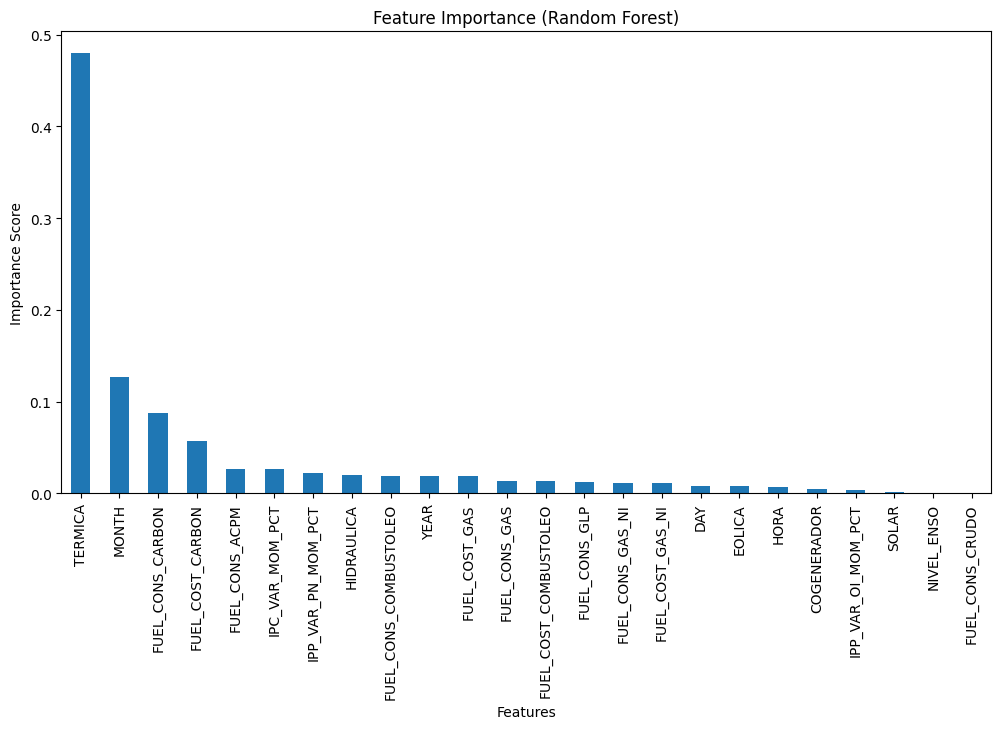

Feature Importance Ranking:
TERMICA                  0.479527
MONTH                    0.126536
FUEL_CONS_CARBON         0.087873
FUEL_COST_CARBON         0.056921
FUEL_CONS_ACPM           0.026761
IPC_VAR_MOM_PCT          0.026706
IPP_VAR_PN_MOM_PCT       0.022032
HIDRAULICA               0.019904
FUEL_CONS_COMBUSTOLEO    0.019489
YEAR                     0.018660
FUEL_COST_GAS            0.018601
FUEL_CONS_GAS            0.014080
FUEL_COST_COMBUSTOLEO    0.013320
FUEL_CONS_GLP            0.012054
FUEL_CONS_GAS_NI         0.011779
FUEL_COST_GAS_NI         0.011133
DAY                      0.008263
EOLICA                   0.007615
HORA                     0.007239
COGENERADOR              0.005008
IPP_VAR_OI_MOM_PCT       0.003298
SOLAR                    0.001890
NIVEL_ENSO               0.000845
FUEL_CONS_CRUDO          0.000465
dtype: float64


In [9]:
# =====================================
# 5. FEATURE IMPORTANCE ANALYSIS (RANDOM FOREST)
# =====================================

# Define target column 'PRECIO'
TARGET_COLUMN = 'PRECIO'

X = df_filtered.drop(columns=[TARGET_COLUMN])
y = df_filtered[TARGET_COLUMN]

# Train the Random Forest model
rf_model = RandomForestRegressor(random_state=42, n_estimators=200)
rf_model.fit(X, y)

# Get feature importance scores
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sort and display the top features
importances_sorted = importances.sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
importances_sorted.plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.xticks(rotation=90)
plt.show()

# Print the ranked feature importance
print("Feature Importance Ranking:")
print(importances_sorted)

(Spanish)

Principales hallazgos:

- TERMICA domina el modelo, aportando casi 48% de la importancia total. Esto sugiere que la generación térmica es el factor más influyente para la variable objetivo.

- Variables temporales (MONTH, YEAR) tienen bastante peso (más de 14% combinadas). Esto indica que hay patrones estacionales y posiblemente tendencias anuales relevantes.

- Variables de combustible y costos (FUEL_CONS_CARBON, FUEL_COST_CARBON, FUEL_CONS_ACPM, etc.) son importantes, pero distribuidas, lo que muestra que cada una aporta algo distinto.

- Variables con importancia muy baja (< 0.005):

    - IPP_VAR_OI_MOM_PCT (0.0032)
    - SOLAR (0.0019)
    - NIVEL_ENSO (0.00085)
    - FUEL_CONS_CRUDO (0.00046)
 

(English)

Key Findings:

- THERMAL generation dominates the model, contributing almost 48% of the total importance. This suggests that thermal generation is the most influential factor for the target variable.

- Time variables (MONTH, YEAR) have significant weight (more than 14% combined). This indicates that there are seasonal patterns and possibly significant annual trends.

- Fuel and cost variables (FUEL_CONS_CARBON, FUEL_COST_CARBON, FUEL_CONS_ACPM, etc.) are important, but distributed, showing that each contributes something different.

- Variables with very low importance (< 0.005):
    
    - IPP_VAR_OI_MOM_PCT (0.0032)
    - SOLAR (0.0019)
    - ENSO_LEVEL (0.00085)
    - CRUDE_FUEL (0.00046)

## Add column index "FECHA_HORA"

In [10]:
fecha_hora_col = pd.to_datetime(
    df[['YEAR', 'MONTH', 'DAY']].astype(str).agg('-'.join, axis=1) + ' ' + df['HORA'].astype(str),
    format='%Y-%m-%d %H'
)

df_filtered.insert(0, 'FECHA_HORA', fecha_hora_col)

## Export filtered dataset

In [11]:
df_filtered

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.00,28880.74,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.00,29107.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.00,25939.87,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.00,25651.57,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.00,25245.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025-06-30 19:00:00,2025,6,30,19,112.55,1311491.62,9025510.46,2476.26,88117.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48188,2025-06-30 20:00:00,2025,6,30,20,112.55,1316147.03,8848494.08,1550.03,93431.69,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48189,2025-06-30 21:00:00,2025,6,30,21,106.25,1376475.95,8510792.32,0.00,95167.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48190,2025-06-30 22:00:00,2025,6,30,22,105.55,1401097.29,8058142.03,0.00,99156.29,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63


In [12]:
#df_filtered.to_csv('../../data/out/dataset_final.csv', index=False)

print("Final Dataset exported...")

Final Dataset exported...
